# MLOps Unit 0 - Colab Reproducibility Anti-Pattern Demo

This notebook shows how an entirely standard data science workflow can undermine reproducibility by relying on a mutable runtime, ad-hoc visual data cleaning, and an automatic dependency export that captures the environment rather than the experiment.


## 1) Imports + environment header

In [6]:
import sys, platform, subprocess, textwrap
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import make_blobs
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



print("python:", sys.version.split()[0])
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", plt.matplotlib.__version__)
# Good practice for reproducibility and debugging, but often avoided in practice
# because it feels opaque, noisy, or irrelevant until something breaks.



python: 3.12.12
platform: Linux-6.6.105+-x86_64-with-glibc2.35
numpy: 2.0.2
sklearn: 1.6.1
matplotlib: 3.10.0


## 2) Generate a simple dataset

X shape: (600, 2) y shape: (600,)


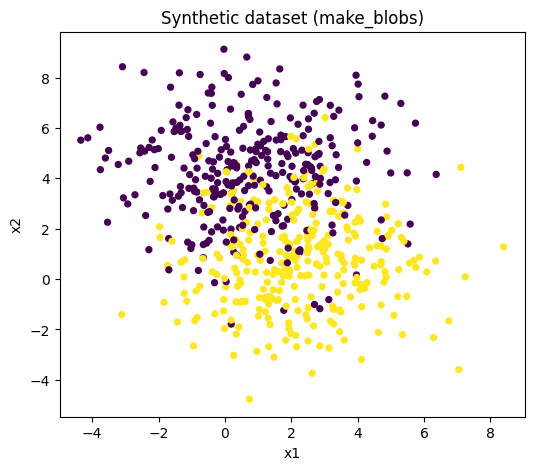

In [7]:
rng = np.random.default_rng(0)

X, y = make_blobs(
    n_samples=600,
    centers=2,
    n_features=2,
    cluster_std=2.0,
    random_state=0
)

print("X shape:", X.shape, "y shape:", y.shape)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=18)
plt.title("Synthetic dataset (make_blobs)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 3) Dirty it a bit (outliers + NaNs)

In [8]:
X_dirty = X.copy()
y_dirty = y.copy()

# Inject some extreme outliers
outlier_idx = rng.choice(len(X_dirty), size=18, replace=False)
X_dirty[outlier_idx] += rng.normal(loc=0, scale=30, size=X_dirty[outlier_idx].shape)

# Inject obvious bad values (NaNs)
nan_idx = rng.choice(len(X_dirty), size=10, replace=False)
X_dirty[nan_idx, 0] = np.nan

# Inject a little label noise too
n_flip = int(0.05 * len(y_dirty))
flip_idx = rng.choice(len(y_dirty), size=n_flip, replace=False)
y_dirty[flip_idx] = 1 - y_dirty[flip_idx]

print("Dirty stats:")
print("  #NaN rows:", np.isnan(X_dirty).any(axis=1).sum())
print("  outliers injected:", len(outlier_idx))
print("  labels flipped:", len(flip_idx))

Dirty stats:
  #NaN rows: 10
  outliers injected: 18
  labels flipped: 30


### Framing note: simulating a real data load

Up to this point, we are **simulating what typically happens when loading a real-world dataset**:
the data is mostly reasonable, but contains a small number of missing values and extreme outliers.
This is the kind of mess that usually only becomes visible after plotting the data.


## 4) Human-in-the-loop data cleaning (anti-pattern)


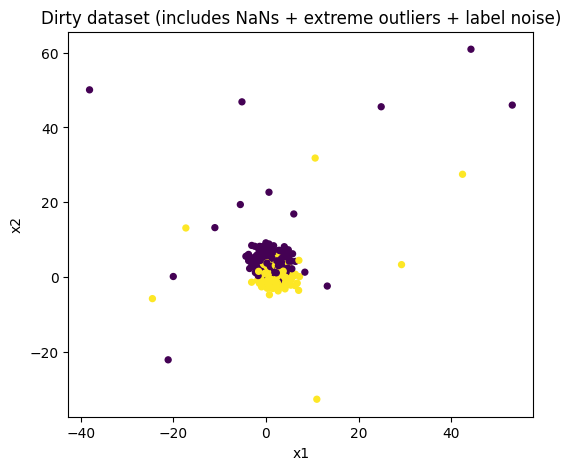

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(X_dirty[:, 0], X_dirty[:, 1], c=y_dirty, s=18)
plt.title("Dirty dataset (includes NaNs + extreme outliers + label noise)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


Now we do the "human in the loop" move:

> *"Looks like anything beyond +/-10 is garbage; also NaNs are garbage."*

Before continuing, ask:
- What happens if the data range changes slightly?
- Would a different person choose the same cutoff?
- Could you recover this decision a month from now without re-looking at the plot?



Cutoff = ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±5
Kept: 443 of 600 (73.8%)


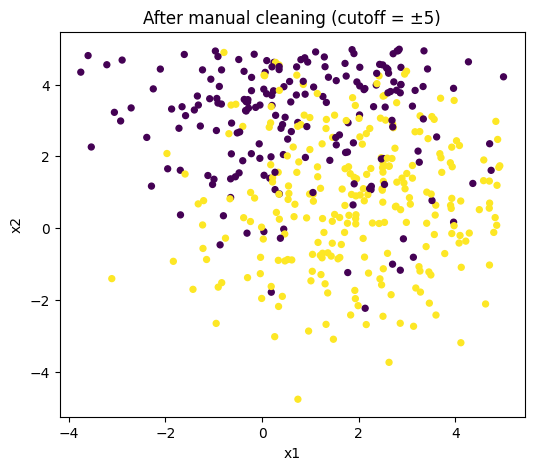

In [21]:
# Human-in-the-loop cleaning: rerun this cell with different cutoffs
# Try values like: 5 (too strict), 20 (too loose), 10 (looks reasonable)

cutoff = 5  # <-- change this and re-run the cell

mask_ok = (
    ~np.isnan(X_dirty).any(axis=1)
    & (np.abs(X_dirty[:, 0]) < cutoff)
    & (np.abs(X_dirty[:, 1]) < cutoff)
)

X_clean = X_dirty[mask_ok]
y_clean = y_dirty[mask_ok]

print(f"Cutoff = +/-{cutoff}")
print("Kept:", len(X_clean), "of", len(X_dirty),
      f"({len(X_clean)/len(X_dirty):.1%})")

plt.figure(figsize=(6, 5))
plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean, s=18)
plt.title(f"After manual cleaning (cutoff = +/-{cutoff})")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


## 5) Standard ML pipeline (SVM)

Best params: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV score: 0.8369630642954856
              precision    recall  f1-score   support

           0      0.806     0.795     0.800        73
           1      0.789     0.800     0.794        70

    accuracy                          0.797       143
   macro avg      0.797     0.797     0.797       143
weighted avg      0.797     0.797     0.797       143



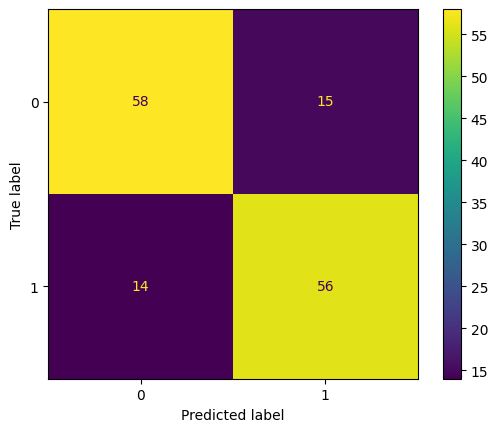

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.25,
    random_state=0,
    stratify=y_clean
)

pipe = make_pipeline(
    StandardScaler(),
    SVC()
)

param_grid = {
    "svc__kernel": ["rbf", "linear"],
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.1, 0.01, 0.001],
}

gs = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV score:", gs.best_score_)

y_pred = gs.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## 6) Problem: environment drift

**Problem:**  
What if I want to run this exact experiment again in a month?

- Colab runtimes change over time.
- Library versions get upgraded or removed.
- The same notebook may produce different results - or fail to run at all.

The issue here is not the model or the data, but the **implicit software environment** the notebook depends on.

**Minimal mitigation:**  
1. **On the first successful run:**  
   Record the current software environment so it becomes explicit rather than implicit.


In [18]:
# `tee` duplicates stdout:
# it prints to the terminal
# and writes to a file at the same time.
!pip freeze | tee requirements.txt

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.1.5.0.43.43
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.31.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.4
catalogue==2.0.10
certifi==2026.1.4
cf

1. **On subsequent runs:**  
    Reinstall those versions at the top of the notebook, before any imports.

In [19]:
!pip install -r requirements.txt

     ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã†â€™Ãƒâ€šÃ

### Why did this fail in Colab?

Colab notebooks run inside a **managed runtime** that includes many preinstalled
packages which are not directly related to this experiment.

When we export dependencies from Colab, the resulting file may include:
- packages that are part of Colab's internal setup
- packages installed from local or non-public sources
- libraries that our code does not explicitly use

As a result, the exported file reflects the **entire runtime environment**, not just
the minimal set of dependencies required for this notebook, and reinstalling all of
them elsewhere may fail.

This highlights an important distinction:  
recording an environment is not the same as defining an experiment's true dependencies.


### Proper environment drift mitigation (preview)

A more robust way to avoid these issues is to work in a **local, user-controlled environment**,
rather than a managed notebook runtime.

In practice, this usually means:
- creating an explicit environment (e.g. using conda)
- installing only the packages the project actually needs



## 7) Problem: how do we rerun this exactly?

In the visual inspection section, we reran the same cleaning cell multiple times:
first removing too much data, then too little, and finally stopping when the result
*looked reasonable*.

This kind of interaction is great for exploration and understanding the data,
but it makes reproduction difficult:
the outcome depends on *how* we interacted with the notebook, not just on the code itself.

**Mitigation:**  
run experiments as non-interactive scripts.